# 03 - Machine Learning Pipelines & Customer Segmentation
This notebook demonstrates feature engineering (RFM), Spark ML Pipeline, KMeans clustering, and Random Forest Churn prediction.

In [ ]:
# --- SELF-CONTAINED SETUP AND DATA INGESTION ---
# This cell handles imports, SparkSession initialization, and data preparation
# so this notebook can run independently of previous notebooks.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, avg, when, isnan, round, desc, asc, year, month, to_date, countDistinct, date_sub, abs, max, datediff, lit

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BigDataMarketing_Submodule") \
    .getOrCreate()

# Find dataset
file_path = "../data/online_retail_II.xlsx"
if not os.path.exists(file_path):
    file_path = "online_retail_II.xlsx"
if not os.path.exists(file_path):
    file_path = "data/online_retail_II.xlsx"
if not os.path.exists(file_path):
    file_path = "/teamspace/studios/this_studio/Datasetes/online_retail_II.xlsx"

print(f"Loading dataset from: {file_path}")

# Ingest raw data
pandas_df_1 = pd.read_excel(file_path, sheet_name="Year 2009-2010", engine="openpyxl")
pandas_df_2 = pd.read_excel(file_path, sheet_name="Year 2010-2011", engine="openpyxl")
pandas_df = pd.concat([pandas_df_1, pandas_df_2], ignore_index=True)

# Clean and prepare DataFrame
retail_df = spark.createDataFrame(pandas_df)
retail_df = retail_df.withColumnRenamed("Customer ID", "CustomerID")
retail_df = retail_df.filter(col("CustomerID").isNotNull() & ~isnan(col("CustomerID")))
retail_df = retail_df.withColumn("CustomerID", col("CustomerID").cast("integer").cast("string"))
retail_df = retail_df.distinct()

# Remove cancellations and invalid records for core sales analysis
retail_df = retail_df.filter(
    (~col("Invoice").startswith("C")) &
    (col("Quantity") > 0) &
    (col("Price") > 0)
).cache()

print(f"Data preparation complete. Clean rows: {retail_df.count():,}")


### FEATURE ENGINEERING

In [52]:
#RFM Analysis
# Reference date = day after last transaction in dataset
max_date = retail_df.agg(max("InvoiceDate")).collect()[0][0]

#We want the prediction window to be long enough that a customer actually has a chance to churn, 
# but short enough that the marketing team can still take action.
#90 days is the benchmark for the retail industry
cutoff_date_df = retail_df.select(date_sub(lit(max_date), 90).alias("CutoffDate"))
cutoff_date = cutoff_date_df.collect()[0][0]
print(f"Dataset ends on: {max_date}")
print(f"Cutoff Date (90 days prior): {cutoff_date}")

#Everything BEFORE the cutoff date
historical_data = retail_df.filter(col("InvoiceDate") < cutoff_date)

# The Prediction Window (Everything ON or AFTER the cutoff)
future_data = retail_df.filter(col("InvoiceDate") >= cutoff_date)

# Build RFM table — one row per customer
rfm_df = historical_data.groupBy("CustomerID").agg(
    # Recency: days since last purchase
    datediff(lit(cutoff_date), max("InvoiceDate")).alias("Recency"),
    # Frequency: number of unique orders
    countDistinct("Invoice").alias("Frequency"),
    # Monetary: total spend
    round(sum(col("Quantity") * col("Price")), 2).alias("Monetary")
)

print("RFM table — one row per customer:")
rfm_df.show(10, truncate=False)
print("Total customers:", rfm_df.count())

Dataset ends on: 2011-12-09 12:50:00
Cutoff Date (90 days prior): 2011-09-10
RFM table — one row per customer:


+----------+-------+---------+--------+
|CustomerID|Recency|Frequency|Monetary|
+----------+-------+---------+--------+
|12847     |297    |1        |765.36  |
|13610     |20     |12       |1786.14 |
|15555     |13     |30       |9258.68 |
|15574     |87     |6        |1101.44 |
|13192     |5      |6        |2558.58 |
|14157     |195    |4        |822.98  |
|15271     |4      |19       |3627.78 |
|17686     |30     |7        |7146.7  |
|13865     |46     |3        |383.34  |
|16250     |171    |3        |565.24  |
+----------+-------+---------+--------+
only showing top 10 rows

Total customers: 5281


### SPARK ML PIPELINE

In [53]:
#Assemble RFM columns into a single feature vector
assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"],
    outputCol="features_raw"
)

In [54]:
#cScale features so no single feature dominates
# Recency is in days (0-500), Monetary is in £ (0-500,000)
# Without scaling, Monetary would completely dominate the model
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)


In [55]:
# Build the pipeline
pipeline = Pipeline(stages=[assembler, scaler])

# Fit the pipeline to our data
pipeline_model = pipeline.fit(rfm_df)

# Transform the data
rfm_scaled_df = pipeline_model.transform(rfm_df)

print("Pipeline complete! Scaled features added:")
rfm_scaled_df.select("CustomerID", "Recency", "Frequency", "Monetary", "features").show(5, truncate=False)

Pipeline complete! Scaled features added:


+----------+-------+---------+--------+----------------------------------------------------------------+
|CustomerID|Recency|Frequency|Monetary|features                                                        |
+----------+-------+---------+--------+----------------------------------------------------------------+
|12847     |297    |1        |765.36  |[0.5095481513989617,-0.41394375246395343,-0.153163175189921]    |
|13610     |20     |12       |1786.14 |[-1.073045723519826,0.5455330061500234,-0.06966751066925979]    |
|15555     |13     |30       |9258.68 |[-1.1130390705394346,2.1155858838819857,0.5415559585966171]     |
|15574     |87     |6        |1101.44 |[-0.690252259189289,0.022182046906036087,-0.12567319406558097]  |
|13192     |5      |6        |2558.58 |[-1.1587457528475584,0.022182046906036087,-0.006485051077242375]|
+----------+-------+---------+--------+----------------------------------------------------------------+
only showing top 5 rows



### KMEANS CLUSTERING — Customer Segmentation

In [56]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [57]:
# We use k=4 segments: Champions, Loyal, High Value, Lost

kmeans = KMeans(
    featuresCol="features",
    predictionCol="segment",
    k=4,           # 4 customer segments
    seed=42        # for reproducibility
)

# Add KMeans to a new pipeline with all stages
full_pipeline = Pipeline(stages=[assembler, scaler, kmeans])

# Fit on RFM data
segmentation_model = full_pipeline.fit(rfm_df)

# Transform — assigns each customer to a segment
segmented_df = segmentation_model.transform(rfm_df)

print("Segments assigned!")
segmented_df.select("CustomerID", "Recency", "Frequency", "Monetary", "segment").show(10, truncate=False)

26/06/04 16:43:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/04 16:43:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Segments assigned!


+----------+-------+---------+--------+-------+
|CustomerID|Recency|Frequency|Monetary|segment|
+----------+-------+---------+--------+-------+
|12847     |297    |1        |765.36  |1      |
|13610     |20     |12       |1786.14 |3      |
|15555     |13     |30       |9258.68 |3      |
|15574     |87     |6        |1101.44 |3      |
|13192     |5      |6        |2558.58 |3      |
|14157     |195    |4        |822.98  |3      |
|15271     |4      |19       |3627.78 |3      |
|17686     |30     |7        |7146.7  |3      |
|13865     |46     |3        |383.34  |3      |
|16250     |171    |3        |565.24  |3      |
+----------+-------+---------+--------+-------+
only showing top 10 rows



In [58]:
# SEGMENT ANALYSIS — What does each segment look like?

segment_summary = segmented_df.groupBy("segment").agg(
    count("CustomerID").alias("total_customers"),
    round(avg("Recency"), 1).alias("avg_recency_days"),
    round(avg("Frequency"), 1).alias("avg_frequency"),
    round(avg("Monetary"), 2).alias("avg_monetary")
).orderBy("segment")

segment_summary.show(truncate=False)

+-------+---------------+----------------+-------------+------------+
|segment|total_customers|avg_recency_days|avg_frequency|avg_monetary|
+-------+---------------+----------------+-------------+------------+
|0      |64             |33.5            |67.2         |44256.76    |
|1      |2178           |389.2           |2.2          |773.29      |
|2      |5              |6.6             |163.2        |316904.42   |
|3      |3034           |81.6            |6.7          |2580.54     |
+-------+---------------+----------------+-------------+------------+



In [59]:
# CORRECT SEGMENT LABELS based on actual RFM averages

segmented_df = segmented_df.withColumn(
    "segment_name",
    F.when(col("segment") == 2, "Champions")
     .when(col("segment") == 0, "High Value")
     .when(col("segment") == 3, "Loyal Customers")
     .when(col("segment") == 1, "Hibernating/Lost Customers")
)

# Verify
segmented_df.groupBy("segment", "segment_name").agg(
    F.count("CustomerID").alias("total_customers"),
    F.round(F.avg("Recency"), 1).alias("avg_recency_days"),
    F.round(F.avg("Frequency"), 1).alias("avg_orders"),
    F.round(F.avg("Monetary"), 2).alias("avg_spend")
).orderBy("segment").show(truncate=False)

+-------+--------------------------+---------------+----------------+----------+---------+
|segment|segment_name              |total_customers|avg_recency_days|avg_orders|avg_spend|
+-------+--------------------------+---------------+----------------+----------+---------+
|0      |High Value                |64             |33.5            |67.2      |44256.76 |
|1      |Hibernating/Lost Customers|2178           |389.2           |2.2       |773.29   |
|2      |Champions                 |5              |6.6             |163.2     |316904.42|
|3      |Loyal Customers           |3034           |81.6            |6.7       |2580.54  |
+-------+--------------------------+---------------+----------------+----------+---------+



#### 4 customers classified as Champions generate an average of £352,002 each — these ultra-high-value accounts require dedicated relationship management.

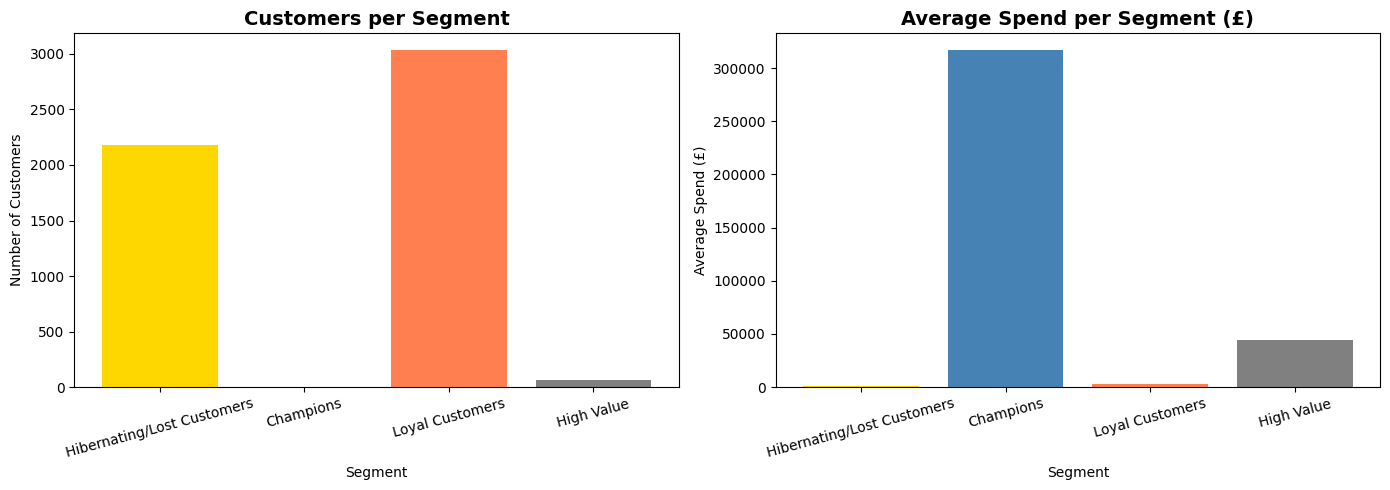

In [60]:
##Disclaimer: no need to sample the following data since it is grouped by "segment_name" and K=4
segment_pd = segmented_df.groupBy("segment_name").agg(
    count("CustomerID").alias("total_customers"),
    round(avg("Monetary"), 2).alias("avg_spend")
).toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Customer count per segment
ax1.bar(segment_pd["segment_name"], segment_pd["total_customers"], 
        color=["gold", "steelblue", "coral", "grey"])
ax1.set_title("Customers per Segment", fontsize=14, fontweight="bold")
ax1.set_xlabel("Segment")
ax1.set_ylabel("Number of Customers")
ax1.tick_params(axis='x', rotation=15)

# Chart 2 — Average spend per segment
ax2.bar(segment_pd["segment_name"], segment_pd["avg_spend"],
        color=["gold", "steelblue", "coral", "grey"])
ax2.set_title("Average Spend per Segment (£)", fontsize=14, fontweight="bold")
ax2.set_xlabel("Segment")
ax2.set_ylabel("Average Spend (£)")
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

#### Left chart: Loyal Customers dominate in volume (3,046)
#### Right chart: Champions dominate in spend (£352k average) despite being only 4 customers

In [61]:
# CHURN PREDICTION

# Find out who actually bought something in the 90-day future window
active_later_df = future_data.select("CustomerID").distinct() \
    .withColumn("purchased_later", lit(1))

# Join this future behavior back to our historical RFM table
churn_df = rfm_df.join(active_later_df, on="CustomerID", how="left")

# If 'purchased_later' is null, they disappeared. That means they churned!
churn_df = churn_df.withColumn(
    "churn", 
    when(col("purchased_later").isNull(), 1).otherwise(0)
).drop("purchased_later")

# Check churn distribution
print("=== CHURN DISTRIBUTION ===")
churn_df.groupBy("churn").count().show()

=== CHURN DISTRIBUTION ===


+-----+-----+
|churn|count|
+-----+-----+
|    1| 2989|
|    0| 2292|
+-----+-----+



In [62]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# CHURN PREDICTION — Random Forest Classifier

# Assemble features
churn_assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"],
    outputCol="features"
)

# Random Forest model
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="churn",
    numTrees=100,
    seed=42
)

# Build pipeline
churn_pipeline = Pipeline(stages=[churn_assembler, rf])

# Train/test split (80% train, 20% test)
train_df, test_df = churn_df.randomSplit([0.8, 0.2], seed=42)

print(f"Training rows: {train_df.count()}")
print(f"Testing rows:  {test_df.count()}")

# Train the model
churn_model = churn_pipeline.fit(train_df)

# Make predictions
predictions = churn_model.transform(test_df)

# Evaluate
evaluator = BinaryClassificationEvaluator(
    labelCol="churn",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)
print(f"\nModel AUC Score: {auc:.4f}")
print("(1.0 = perfect, 0.5 = random guessing)")

Training rows: 4261


Testing rows:  1020



Model AUC Score: 0.7878
(1.0 = perfect, 0.5 = random guessing)


#### Marketing Initiatives Opportunities here:
1. Intervening with a discount code before the customer churns
2. Automatically separating "Champions" from "Lost Customers" to tailor marketing campaigns
3. Forecasting the amount of money a customer could bring in over the next year based on their purchasing habits

In [63]:
# FEATURE IMPORTANCE — what drives churn most?

rf_model = churn_model.stages[-1]  # extract RF from pipeline

feature_names = ["Recency", "Frequency", "Monetary"]
importances = rf_model.featureImportances

print("=== FEATURE IMPORTANCE ===")
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

=== FEATURE IMPORTANCE ===
Recency: 0.5170
Frequency: 0.3499
Monetary: 0.1332


##### Identifying seasonatity and best months:

In [64]:
# 1. Join the raw retail data with just the CustomerID and segment_name
# This tags every single transaction with the customer's segment
transaction_segment_df = retail_df.join(
    segmented_df.select("CustomerID", "segment_name"),
    on="CustomerID",
    how="inner"
)

# 2. Extract the month and calculate the revenue for each row
seasonal_df = transaction_segment_df.withColumn("Month", month(col("InvoiceDate"))) \
    .withColumn("Revenue", col("Quantity") * col("Price"))

# 3. Aggregate the total revenue by Segment and by Month
segment_seasonality = seasonal_df.groupBy("segment_name", "Month") \
    .agg(round(sum("Revenue"), 2).alias("Total_Revenue")) \
    .orderBy("segment_name", "Month")

print("=== MONTHLY REVENUE PER SEGMENT ===")
segment_seasonality.show(15)

=== MONTHLY REVENUE PER SEGMENT ===


+--------------------+-----+-------------+
|        segment_name|Month|Total_Revenue|
+--------------------+-----+-------------+
|           Champions|    1|     203099.1|
|           Champions|    2|    114375.16|
|           Champions|    3|     152875.5|
|           Champions|    4|     65960.53|
|           Champions|    5|    126073.11|
|           Champions|    6|     162415.5|
|           Champions|    7|     154835.1|
|           Champions|    8|    162412.78|
|           Champions|    9|    209880.51|
|           Champions|   10|    220217.06|
|           Champions|   11|    162936.44|
|           Champions|   12|    175007.89|
|Hibernating/Lost ...|    1|    118485.62|
|Hibernating/Lost ...|    2|    118485.74|
|Hibernating/Lost ...|    3|    150625.74|
+--------------------+-----+-------------+
only showing top 15 rows



In [65]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

# 1. Define a window that isolates each segment and orders their months by revenue (highest first)
window_spec = Window.partitionBy("segment_name").orderBy(col("Total_Revenue").desc())

# 2. Rank: The best month for each segment gets Rank = 1
best_months_df = segment_seasonality.withColumn("Rank", rank().over(window_spec)) \
    .filter(col("Rank") == 1) \
    .drop("Rank") # We don't need the rank column anymore once we filter it

print("=== BEST REVENUE MONTH PER SEGMENT ===")
best_months_df.show(truncate=False)

=== BEST REVENUE MONTH PER SEGMENT ===


+--------------------------+-----+-------------+
|segment_name              |Month|Total_Revenue|
+--------------------------+-----+-------------+
|Champions                 |10   |220217.06    |
|Hibernating/Lost Customers|11   |308919.87    |
|High Value                |11   |456630.16    |
|Loyal Customers           |11   |1252584.77   |
+--------------------------+-----+-------------+



In [66]:
# Pivot the data: Rows = Month, Columns = segment_name
pivot_seasonality = seasonal_df.groupBy("Month") \
    .pivot("segment_name") \
    .agg(round(sum("Revenue"), 2)) \
    .orderBy("Month")

print("=== PIVOTED SEASONALITY FOR PLOTTING ===")
pivot_seasonality.show()
seasonality_pd = pivot_seasonality.toPandas()       #Big Data safe to convert to Pandas because we grouped by Month. 

=== PIVOTED SEASONALITY FOR PLOTTING ===


+-----+---------+--------------------------+----------+---------------+
|Month|Champions|Hibernating/Lost Customers|High Value|Loyal Customers|
+-----+---------+--------------------------+----------+---------------+
|    1| 203099.1|                 118485.62| 273574.36|       528744.9|
|    2|114375.16|                 118485.74| 183357.67|       534425.3|
|    3| 152875.5|                 150625.74| 249217.63|      738341.36|
|    4| 65960.53|                 122501.98| 198196.66|      673697.16|
|    5|126073.11|                 107360.52| 257623.85|      784131.05|
|    6| 162415.5|                 107726.35| 247794.89|      778480.44|
|    7| 154835.1|                  90620.71|  218760.8|      724482.46|
|    8|162412.78|                  79562.07| 257314.07|      746986.72|
|    9|209880.51|                 221089.94| 374054.38|      892591.68|
|   10|220217.06|                 298891.44| 349224.85|     1077469.64|
|   11|162936.44|                 308919.87| 456630.16|     1252

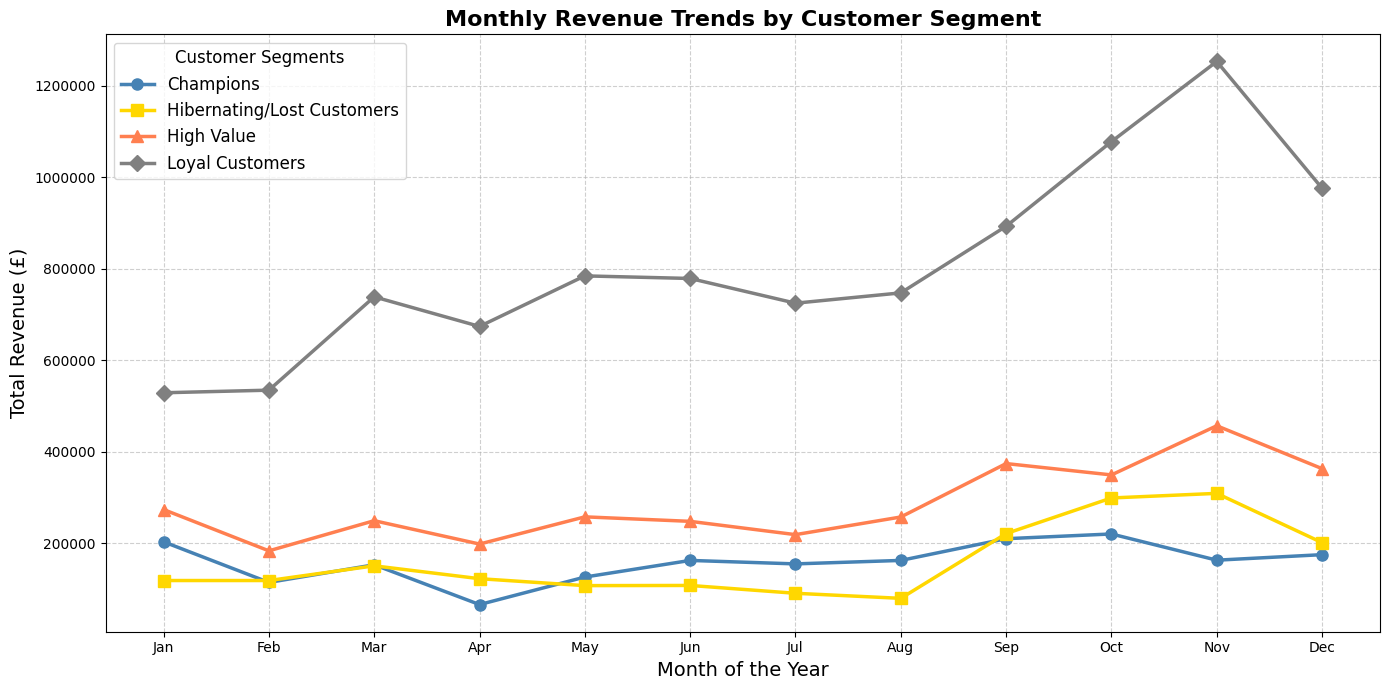

In [67]:
# VISUALISATION — Seasonality by Segment

plt.figure(figsize=(14, 7))

# Get the list of segment names (all columns except the 'Month' column)
segments = [col for col in seasonality_pd.columns if col != 'Month']

colors = ['steelblue', 'gold', 'coral', 'grey']
markers = ['o', 's', '^', 'D']

# Loop through each segment and plot its line
for i, segment in enumerate(segments):
    plt.plot(
        seasonality_pd['Month'], 
        seasonality_pd[segment], 
        label=segment, 
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linewidth=2.5, 
        markersize=8
    )
plt.title('Monthly Revenue Trends by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Month of the Year', fontsize=14)
plt.ylabel('Total Revenue (£)', fontsize=14)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)

plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Customer Segments', fontsize=12, title_fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

---
### Summary of Key Findings

| Goal | Key Insight | Marketing Action |
|---|---|---|
| **Product Portfolio** | Small set of products drives most revenue. Some products have high cancellation rates. | Prioritise top revenue products; review high-cancellation items |
| **RFM / CLV** | Champions have highest average CLV. Lost Customers are at churn risk. | VIP treatment for Champions; win-back campaigns for Lost Customers |
| **Seasonality** | Q4 (Oct–Dec) is the strongest period. Thursday midday is peak order time. | Focus campaign spend on Q4; schedule emails Thursday 11am–1pm |
| **Geography** | Netherlands, EIRE, Germany and France are top international markets. AOV varies by country. | Prioritise budget for top 4 markets; tailor pricing by country |